# Data Readiness — O dataset está pronto para o modelo?

Este notebook responde sistematicamente às perguntas críticas **antes** de qualquer treinamento.

**Objetivo:** auditar o dataset `telco_churn.csv` e documentar todas as decisões de pré-processamento com justificativa.

| Checklist | Status |
|-----------|--------|
| 1. Schema e tipos de dados | ✅ |
| 2. Valores ausentes e inválidos | ✅ |
| 3. Plano de encoding categórico | ✅ |
| 4. Escala das variáveis numéricas | ✅ |
| 5. Multicolinearidade | ✅ |
| 6. Balanceamento do target | ✅ |
| 7. Estratégia de split treino/teste | ✅ |
| 8. Seleção de features | ✅ |
| 9. Veredicto final | ✅ |

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})

DATA_PATH = "../data/raw/telco_churn.csv"
SEED = 42

## 1. Schema e tipos de dados

Primeiro passo: entender o que o dataset contém antes de qualquer transformação.

In [2]:
df_raw = pd.read_csv(DATA_PATH)

print(f"Shape: {df_raw.shape[0]:,} linhas × {df_raw.shape[1]} colunas\n")
print(
    df_raw.dtypes.to_frame(name="dtype")
    .assign(n_unique=df_raw.nunique(), exemplo=df_raw.iloc[0])
    .to_string()
)

Shape: 7,043 linhas × 21 colunas

                    dtype  n_unique           exemplo
customerID         object      7043        7590-VHVEG
gender             object         2            Female
SeniorCitizen       int64         2                 0
Partner            object         2               Yes
Dependents         object         2                No
tenure              int64        73                 1
PhoneService       object         2                No
MultipleLines      object         3  No phone service
InternetService    object         3               DSL
OnlineSecurity     object         3                No
OnlineBackup       object         3               Yes
DeviceProtection   object         3                No
TechSupport        object         3                No
StreamingTV        object         3                No
StreamingMovies    object         3                No
Contract           object         3    Month-to-month
PaperlessBilling   object         2             

In [ ]:
object_cols  = df_raw.select_dtypes("object").columns.tolist()
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()

print(f"Colunas object   ({len(object_cols)}): {object_cols}")
print(f"Colunas numéricas ({len(numeric_cols)}): {numeric_cols}")
print()
print("⚠  TotalCharges deveria ser float64, mas está como object -> coerção necessária.")

Colunas object   (18): ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']
Colunas numéricas (3): ['SeniorCitizen', 'tenure', 'MonthlyCharges']

⚠  TotalCharges deveria ser float64, mas está como object → coerção necessária.


## 2. Valores ausentes e inválidos

Verificar nulos explícitos (`NaN`) **e** valores inválidos mascarados (espaços em branco, strings não conversíveis).

In [4]:
# Nulos explícitos
nulls = df_raw.isnull().sum()
print("Nulos por coluna (antes da coerção):")
print(nulls[nulls > 0] if nulls.any() else "  Nenhum nulo explícito encontrado.")

# Inválidos em TotalCharges (strings não numéricas)
tc_invalid = pd.to_numeric(df_raw["TotalCharges"], errors="coerce").isna()
print(f"\nLinhas com TotalCharges inválido (não numérico): {tc_invalid.sum()}")
if tc_invalid.sum() > 0:
    print(df_raw[tc_invalid][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])

Nulos por coluna (antes da coerção):
  Nenhum nulo explícito encontrado.

Linhas com TotalCharges inválido (não numérico): 11
      customerID  tenure  MonthlyCharges TotalCharges Churn
488   4472-LVYGI       0           52.55                 No
753   3115-CZMZD       0           20.25                 No
936   5709-LVOEQ       0           80.85                 No
1082  4367-NUYAO       0           25.75                 No
1340  1371-DWPAZ       0           56.05                 No
3331  7644-OMVMY       0           19.85                 No
3826  3213-VVOLG       0           25.35                 No
4380  2520-SGTTA       0           20.00                 No
5218  2923-ARZLG       0           19.70                 No
6670  4075-WKNIU       0           73.35                 No
6754  2775-SEFEE       0           61.90                 No


In [5]:
# Aplicar coerção e remover as linhas inválidas
df = df_raw.copy()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

n_before = len(df)
df.dropna(subset=["TotalCharges"], inplace=True)
df.reset_index(drop=True, inplace=True)
n_removed = n_before - len(df)

print(f"Linhas removidas: {n_removed} (tenure=0, sem cobrança registrada)")
print(f"Dataset final: {len(df):,} linhas")
print()

nulls_after = df.isnull().sum()
print("Nulos após coerção:")
print(nulls_after[nulls_after > 0] if nulls_after.any() else "  Nenhum nulo restante. Dataset completo. ✅")

Linhas removidas: 11 (tenure=0, sem cobrança registrada)
Dataset final: 7,032 linhas

Nulos após coerção:
  Nenhum nulo restante. Dataset completo. ✅


## 3. Plano de encoding categórico

Modelos de ML não aceitam strings. Cada coluna categórica precisa de uma estratégia de encoding adequada.

| Estratégia | Quando usar | Risco |
|---|---|---|
| **OrdinalEncoder** | Binárias (2 valores) | Nenhum — a ordem é arbitrária mas inofensiva |
| **OneHotEncoder** | Multi-classe (>2 valores) | Explosão de dimensionalidade se muitas categorias |
| **Target Encoding** | Alta cardinalidade | Data leakage se mal aplicado |

In [10]:
cat_cols = [
    c for c in df.select_dtypes("object").columns
    if c not in ("customerID", "Churn")
]

print(f"{'Coluna':<22} {'n_unique':>8}  {'Encoding':<18}  Valores")
print("-" * 90)

binary_cols = []
ohe_cols    = []

for col in cat_cols:
    n    = df[col].nunique()
    vals = df[col].unique().tolist()
    enc  = "OrdinalEncoder" if n == 2 else "OneHotEncoder"
    if n == 2:
        binary_cols.append(col)
    else:
        ohe_cols.append(col)
    print(f"  {col:<20} {n:>8}  {enc:<18}  {vals}")

print(f"\nBinárias     ({len(binary_cols)}): {binary_cols}")
print(f"Multi-classe ({len(ohe_cols)}): {ohe_cols}")

ohe_dims   = sum(df[c].nunique() - 1 for c in ohe_cols)  # drop='first'
total_dims = len(binary_cols) + ohe_dims + 3               # 3 numéricas retidas
print(f"\nDimensionalidade estimada após encoding: {total_dims} features")

Coluna                 n_unique  Encoding            Valores
------------------------------------------------------------------------------------------
  gender                      2  OrdinalEncoder      ['Female', 'Male']
  Partner                     2  OrdinalEncoder      ['Yes', 'No']
  Dependents                  2  OrdinalEncoder      ['No', 'Yes']
  PhoneService                2  OrdinalEncoder      ['No', 'Yes']
  MultipleLines               3  OneHotEncoder       ['No phone service', 'No', 'Yes']
  InternetService             3  OneHotEncoder       ['DSL', 'Fiber optic', 'No']
  OnlineSecurity              3  OneHotEncoder       ['No', 'Yes', 'No internet service']
  OnlineBackup                3  OneHotEncoder       ['Yes', 'No', 'No internet service']
  DeviceProtection            3  OneHotEncoder       ['No', 'Yes', 'No internet service']
  TechSupport                 3  OneHotEncoder       ['No', 'Yes', 'No internet service']
  StreamingTV                 3  OneHotEncoder

## 4. Escala das variáveis numéricas

Variáveis em escalas muito diferentes prejudicam modelos baseados em distância (Regressão Logística, SVM, KNN).

**Decisão:** aplicar `StandardScaler` em todas as variáveis numéricas retidas.

Estatísticas descritivas — variáveis numéricas:
        tenure  MonthlyCharges  TotalCharges
count  7032.00         7032.00       7032.00
mean     32.42           64.80       2283.30
std      24.55           30.09       2266.77
min       1.00           18.25         18.80
25%       9.00           35.59        401.45
50%      29.00           70.35       1397.48
75%      55.00           89.86       3794.74
max      72.00          118.75       8684.80


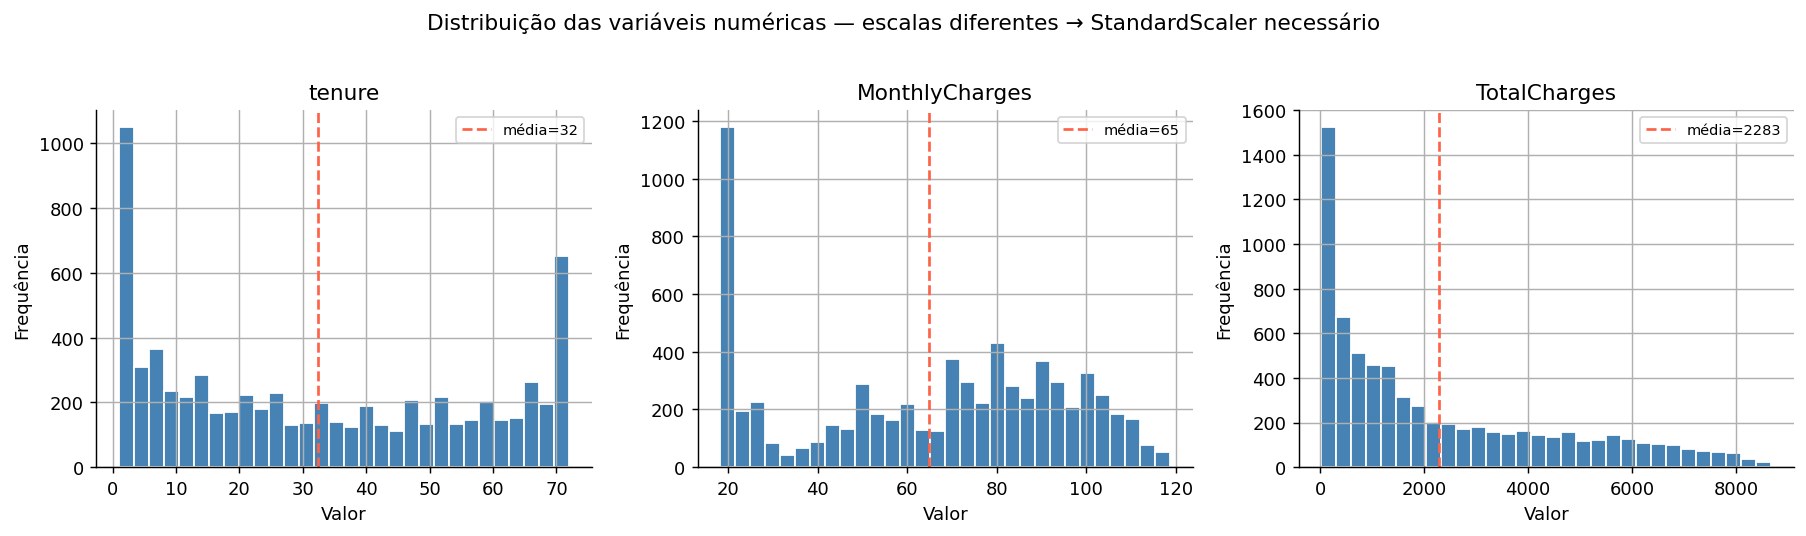

In [11]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

print("Estatísticas descritivas — variáveis numéricas:")
print(df[num_cols].describe().round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, num_cols):
    df[col].hist(bins=30, ax=ax, color="steelblue", edgecolor="white")
    ax.axvline(df[col].mean(), color="tomato", ls="--", lw=1.5, label=f"média={df[col].mean():.0f}")
    ax.set_title(col)
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frequência")
    ax.legend(fontsize=8)

plt.suptitle("Distribuição das variáveis numéricas — escalas diferentes → StandardScaler necessário", y=1.02)
plt.tight_layout()
plt.show()

## 5. Multicolinearidade

**Suspeita:** `TotalCharges ≈ tenure × MonthlyCharges`

Correlação muito alta (> 0.85) entre features indica redundância e pode causar instabilidade em modelos lineares (coeficientes inflados, gradientes instáveis).

Matriz de correlação (Pearson):
                tenure  MonthlyCharges  TotalCharges
tenure           1.000           0.247         0.826
MonthlyCharges   0.247           1.000         0.651
TotalCharges     0.826           0.651         1.000


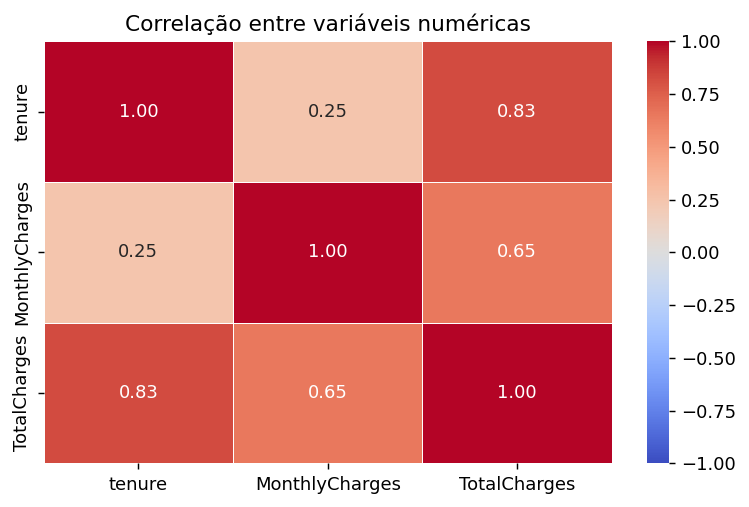


Correlação TotalCharges ~ tenure        : 0.826
Correlação TotalCharges ~ MonthlyCharges: 0.651


In [12]:
corr = df[num_cols].corr()

print("Matriz de correlação (Pearson):")
print(corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title("Correlação entre variáveis numéricas")
plt.tight_layout()
plt.show()

tc_tenure  = corr.loc["TotalCharges", "tenure"]
tc_monthly = corr.loc["TotalCharges", "MonthlyCharges"]
print(f"\nCorrelação TotalCharges ~ tenure        : {tc_tenure:.3f}")
print(f"Correlação TotalCharges ~ MonthlyCharges: {tc_monthly:.3f}")
if tc_tenure > 0.85:
    print("\n⚠  Alta multicolinearidade → TotalCharges será REMOVIDO do modelo.")
    print("   TotalCharges ≈ tenure × MonthlyCharges: não acrescenta informação independente.")

## 6. Balanceamento do target

Datasets desbalanceados fazem o modelo aprender a prever sempre a classe majoritária.

Com ~73% "No" e ~27% "Yes", um modelo ingênuo teria **73% de acurácia** prevendo sempre "Não-churn" — mas **Recall para churn seria 0%**, o que é inútil para o negócio.

> **Por que PR-AUC e não Accuracy?**
> PR-AUC mede o trade-off entre Precisão e Recall focando na classe minoritária (churn),
> sendo muito mais informativa do que acurácia em cenários desbalanceados.

Distribuição do target (Churn):
  No   ████████████████████████████████████       5163 (73.4%)
  Yes  █████████████                              1869 (26.6%)

Razão majoritária/minoritária: 2.8x


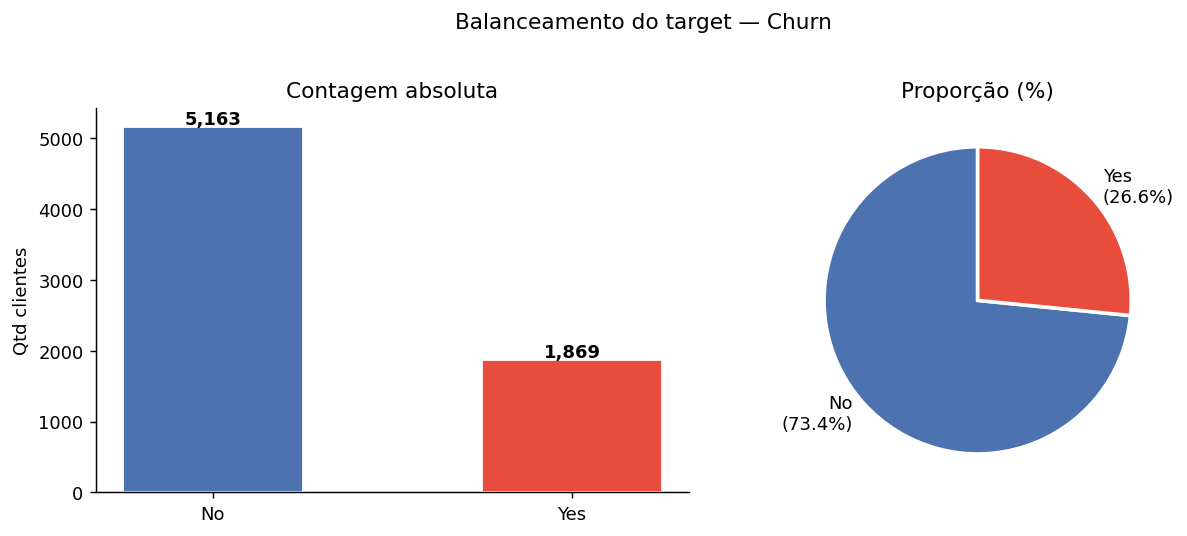


Mitigações:
  • class_weight='balanced' nos estimadores sklearn
  • Stratified split (mantém proporção em treino e teste)
  • Métrica primária: PR-AUC | Secundária: AUC-ROC, F1


In [13]:
churn_counts = df["Churn"].value_counts()
churn_pct    = df["Churn"].value_counts(normalize=True) * 100

print("Distribuição do target (Churn):")
for label in ["No", "Yes"]:
    bar = "█" * int(churn_pct[label] / 2)
    print(f"  {label:<4} {bar:<40}  {churn_counts[label]:>5} ({churn_pct[label]:.1f}%)")

ratio = churn_counts["No"] / churn_counts["Yes"]
print(f"\nRazão majoritária/minoritária: {ratio:.1f}x")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ["#4C72B0", "#E74C3C"]

axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor="white", width=0.5)
axes[0].set_title("Contagem absoluta")
axes[0].set_ylabel("Qtd clientes")
for i, (label, val) in enumerate(zip(churn_counts.index, churn_counts.values)):
    axes[0].text(i, val + 40, f"{val:,}", ha="center", fontweight="bold")

axes[1].pie(
    churn_counts.values,
    labels=[f"{l}\n({churn_pct[l]:.1f}%)" for l in churn_counts.index],
    colors=colors, startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[1].set_title("Proporção (%)")

plt.suptitle("Balanceamento do target — Churn", y=1.02)
plt.tight_layout()
plt.show()

print("\nMitigações:")
print("  • class_weight='balanced' nos estimadores sklearn")
print("  • Stratified split (mantém proporção em treino e teste)")
print("  • Métrica primária: PR-AUC | Secundária: AUC-ROC, F1")

## 7. Estratégia de split treino/teste

**Regras:**
- Split **80/20** estratificado por `Churn` — preserva a proporção do target em ambos os conjuntos
- `random_state=42` — reprodutibilidade garantida
- `StandardScaler` e encoders serão fitados **apenas no treino** e aplicados no teste (sem data leakage)

Total   :  7032 amostras  |  18 features
Treino  :  5625 (80.0%)  |  churn rate: 26.6%
Teste   :  1407 (20.0%)  |  churn rate: 26.6%

Proporção do target preservada: ✅


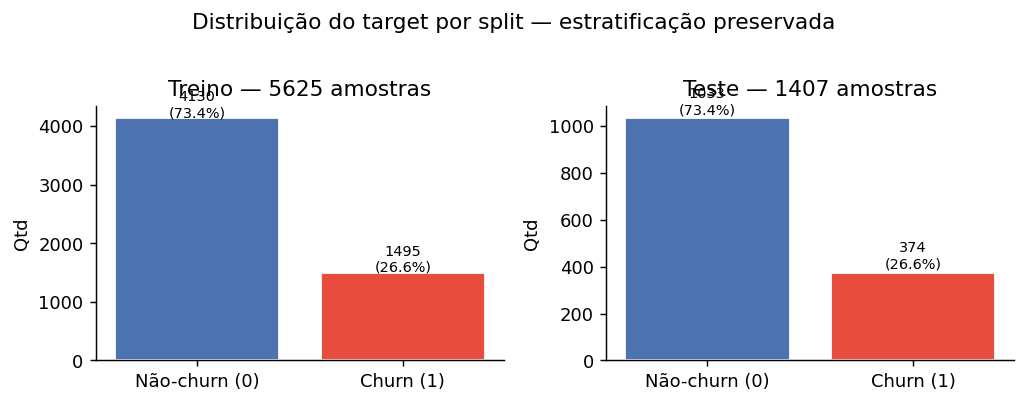

In [14]:
y = df["Churn"].map({"Yes": 1, "No": 0})
X = df.drop(columns=["customerID", "Churn", "TotalCharges"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f"Total   : {len(df):>5} amostras  |  {X.shape[1]} features")
print(f"Treino  : {len(X_train):>5} ({len(X_train)/len(df)*100:.1f}%)  |  churn rate: {y_train.mean():.1%}")
print(f"Teste   : {len(X_test):>5} ({len(X_test)/len(df)*100:.1f}%)  |  churn rate: {y_test.mean():.1%}")
drift = abs(y_train.mean() - y_test.mean())
print(f"\nProporção do target preservada: {'✅' if drift < 0.005 else '⚠  Drift = ' + f'{drift:.4f}'}")

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for ax, (name, y_split) in zip(axes, [("Treino", y_train), ("Teste", y_test)]):
    counts = y_split.value_counts().sort_index()
    ax.bar(["Não-churn (0)", "Churn (1)"], counts.values, color=["#4C72B0", "#E74C3C"], edgecolor="white")
    ax.set_title(f"{name} — {len(y_split)} amostras")
    ax.set_ylabel("Qtd")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 20, f"{v}\n({v/len(y_split):.1%})", ha="center", fontsize=8)

plt.suptitle("Distribuição do target por split — estratificação preservada", y=1.02)
plt.tight_layout()
plt.show()

## 8. Seleção de features

Antes de treinar, definir explicitamente quais features entram e por quê.

In [15]:
decisions = {
    "customerID":       ("REMOVER", "Identificador único — sem poder preditivo"),
    "TotalCharges":     ("REMOVER", "Alta multicolinearidade com tenure (r > 0.85) — redundante"),
    "SeniorCitizen":    ("MANTER",  "Binária numérica — StandardScaler"),
    "tenure":           ("MANTER",  "Forte sinal preditivo — StandardScaler"),
    "MonthlyCharges":   ("MANTER",  "Forte sinal preditivo — StandardScaler"),
    "gender":           ("MANTER",  "Binária — OrdinalEncoder"),
    "Partner":          ("MANTER",  "Binária — OrdinalEncoder"),
    "Dependents":       ("MANTER",  "Binária — OrdinalEncoder"),
    "PhoneService":     ("MANTER",  "Binária — OrdinalEncoder"),
    "PaperlessBilling": ("MANTER",  "Binária — OrdinalEncoder"),
    "MultipleLines":    ("MANTER",  "Multi-classe — OneHotEncoder(drop=first)"),
    "InternetService":  ("MANTER",  "Multi-classe — OneHotEncoder(drop=first)"),
    "OnlineSecurity":   ("MANTER",  "Multi-classe — OneHotEncoder(drop=first)"),
    "OnlineBackup":     ("MANTER",  "Multi-classe — OneHotEncoder(drop=first)"),
    "DeviceProtection": ("MANTER",  "Multi-classe — OneHotEncoder(drop=first)"),
    "TechSupport":      ("MANTER",  "Multi-classe — OneHotEncoder(drop=first)"),
    "StreamingTV":      ("MANTER",  "Multi-classe — OneHotEncoder(drop=first)"),
    "StreamingMovies":  ("MANTER",  "Multi-classe — OneHotEncoder(drop=first)"),
    "Contract":         ("MANTER",  "Multi-classe — OneHotEncoder(drop=first)"),
    "PaymentMethod":    ("MANTER",  "Multi-classe — OneHotEncoder(drop=first)"),
}

print(f"{'Coluna':<22} {'Decisão':<10}  Justificativa")
print("-" * 80)
for col, (decision, reason) in decisions.items():
    marker = "✅" if decision == "MANTER" else "❌"
    print(f"  {col:<20} {marker} {decision:<8}  {reason}")

n_kept    = sum(1 for d, _ in decisions.values() if d == "MANTER")
n_dropped = sum(1 for d, _ in decisions.values() if d == "REMOVER")
print(f"\nTotal: {n_kept} features mantidas | {n_dropped} removidas")

Coluna                 Decisão     Justificativa
--------------------------------------------------------------------------------
  customerID           ❌ REMOVER   Identificador único — sem poder preditivo
  TotalCharges         ❌ REMOVER   Alta multicolinearidade com tenure (r > 0.85) — redundante
  SeniorCitizen        ✅ MANTER    Binária numérica — StandardScaler
  tenure               ✅ MANTER    Forte sinal preditivo — StandardScaler
  MonthlyCharges       ✅ MANTER    Forte sinal preditivo — StandardScaler
  gender               ✅ MANTER    Binária — OrdinalEncoder
  Partner              ✅ MANTER    Binária — OrdinalEncoder
  Dependents           ✅ MANTER    Binária — OrdinalEncoder
  PhoneService         ✅ MANTER    Binária — OrdinalEncoder
  PaperlessBilling     ✅ MANTER    Binária — OrdinalEncoder
  MultipleLines        ✅ MANTER    Multi-classe — OneHotEncoder(drop=first)
  InternetService      ✅ MANTER    Multi-classe — OneHotEncoder(drop=first)
  OnlineSecurity       ✅ MANTE

## 9. Churn rate por feature categórica

Validar que as features retidas possuem poder discriminatório real antes de entrar no modelo.

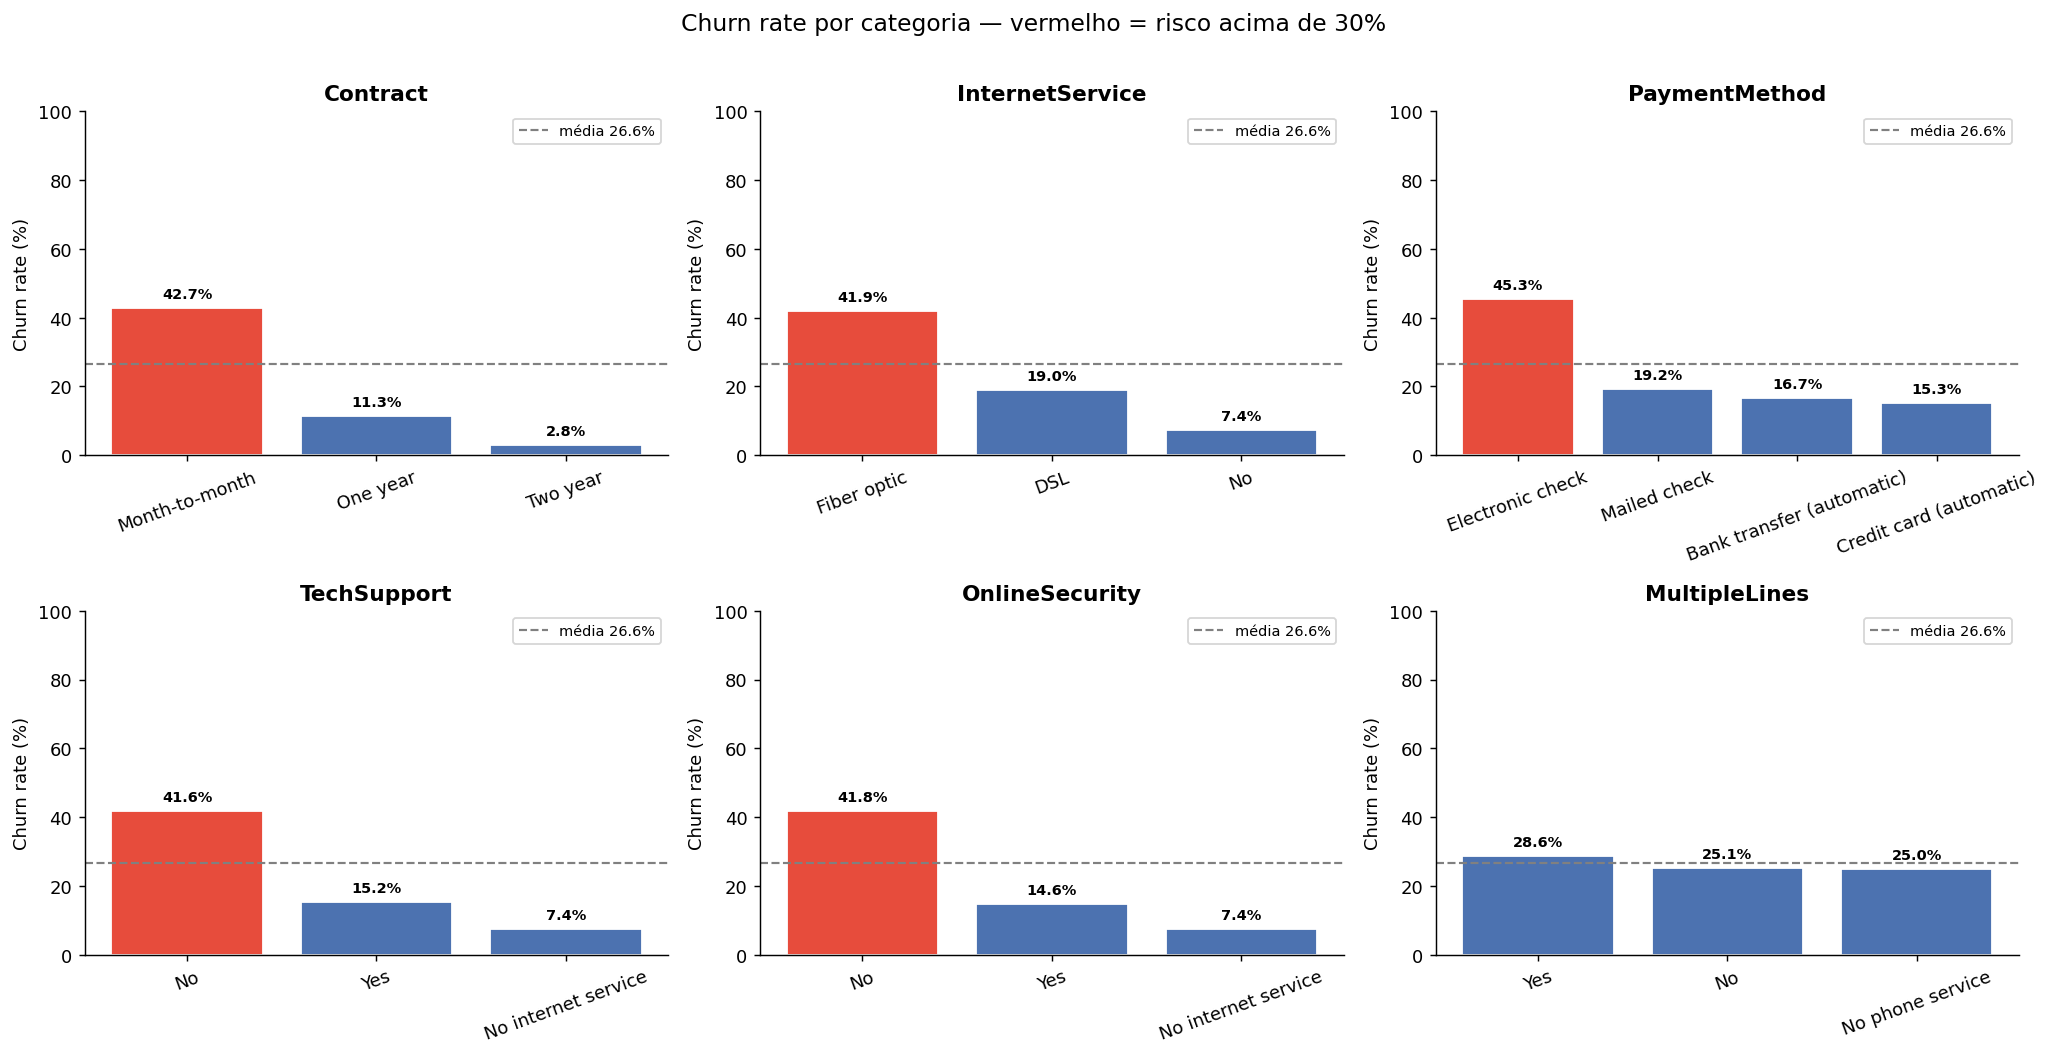

In [16]:
cat_features_plot = [
    "Contract", "InternetService", "PaymentMethod",
    "TechSupport", "OnlineSecurity", "MultipleLines",
]
global_churn = df["Churn"].eq("Yes").mean() * 100

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, cat_features_plot):
    churn_rate = (
        df.groupby(col)["Churn"]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )
    bar_colors = ["#E74C3C" if v > 30 else "#4C72B0" for v in churn_rate.values]
    bars = ax.bar(churn_rate.index, churn_rate.values, color=bar_colors, edgecolor="white")
    ax.axhline(global_churn, color="gray", ls="--", lw=1.2, label=f"média {global_churn:.1f}%")
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("Churn rate (%)")
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, churn_rate.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=8, fontweight="bold")

plt.suptitle("Churn rate por categoria — vermelho = risco acima de 30%", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## 10. Veredicto Final — Data Readiness Report

In [ ]:
report = [
    ("Schema",             "ok", f"{df.shape[0]:,} linhas × {df.shape[1]} colunas, tipos corrigidos"),
    ("Nulos",              "ok", f"{n_removed} linhas removidas (TotalCharges inválido, tenure=0)"),
    ("Encoding",           "ok", f"{len(binary_cols)} binárias -> OrdinalEncoder | {len(ohe_cols)} multi-classe -> OneHotEncoder(drop=first)"),
    ("Escala",             "ok", "StandardScaler em SeniorCitizen, tenure, MonthlyCharges"),
    ("Multicolinearidade", "ok", "TotalCharges removido (r > 0.85 com tenure)"),
    ("Desbalanceamento",   "ok", "73% No / 27% Yes -> class_weight='balanced' + PR-AUC como métrica primária"),
    ("Split",              "ok", "80/20 estratificado, random_state=42, sem data leakage"),
    ("Features finais",    "ok", f"{X.shape[1]} features de entrada após remoção de customerID e TotalCharges"),
]

print("=" * 72)
print("  DATA READINESS REPORT — telco_churn.csv")
print("=" * 72)
for item, status, detail in report:
    print(f"  {status}  {item:<22}  {detail}")
print("=" * 72)
print()
print("VEREDICTO: Dataset pronto para treinamento.")
print("Próximo passo → notebooks/Baselines.ipynb")

  DATA READINESS REPORT — telco_churn.csv
  ✅  Schema                  7,032 linhas × 21 colunas, tipos corrigidos
  ✅  Nulos                   11 linhas removidas (TotalCharges inválido, tenure=0)
  ✅  Encoding                5 binárias → OrdinalEncoder | 10 multi-classe → OneHotEncoder(drop=first)
  ✅  Escala                  StandardScaler em SeniorCitizen, tenure, MonthlyCharges
  ✅  Multicolinearidade      TotalCharges removido (r > 0.85 com tenure)
  ✅  Desbalanceamento        73% No / 27% Yes → class_weight='balanced' + PR-AUC como métrica primária
  ✅  Split                   80/20 estratificado, random_state=42, sem data leakage
  ✅  Features finais         18 features de entrada após remoção de customerID e TotalCharges

VEREDICTO: Dataset pronto para treinamento.
Próximo passo → notebooks/Baselines.ipynb


## Decisões herdadas pelos notebooks seguintes

| Decisão | Valor |
|---------|-------|
| `DATA_PATH` | `../data/raw/telco_churn.csv` |
| Features removidas | `customerID`, `TotalCharges` |
| Numéricas (StandardScaler) | `SeniorCitizen`, `tenure`, `MonthlyCharges` |
| Binárias (OrdinalEncoder) | `gender`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling` |
| Multi-classe (OHE drop=first) | `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaymentMethod` |
| Split | 80/20 estratificado, `random_state=42` |
| Métrica primária | PR-AUC |
| Métrica secundária | AUC-ROC, F1 |
| Desbalanceamento | `class_weight='balanced'` |